# Assortativity analysis of an EpiLink compatibility network

The default run is intentionally scoped to one real window-lineage group. The full pairwise directory is very large, so widen the filters only after checking memory and runtime.

Workflow:

1. Configure the real metadata and pairwise edge slice
2. Load sequence-level metadata with policy labels
3. Load filtered EpiLink edges with Parquet projection and predicate pushdown
4. Align edge endpoints to the analysis metadata
5. Build a weighted NetworkX graph
6. Summarise node attributes, edge weights, mixing, assortativity, communities, and threshold sensitivity

In [1]:
from __future__ import annotations

from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import networkx as nx

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "utils").exists() and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "utils").exists():
    raise RuntimeError("Run this notebook from inside the scotland repository.")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from utils import load_analysis_columns, load_pairwise_edges  # noqa: E402

sns.set_theme(style="whitegrid", context="notebook")
SEED = 42
rng = np.random.default_rng(SEED)

## Analysis configuration

The pairwise EpiLink dataset is stored as many Parquet files and can be billions of filtered rows if read broadly. The parameters below keep the notebook executable by focusing on one window-clade slice.

`renumber_windows=False` is important when using `window_stride`: it preserves the original window labels (`W001`, `W003`, ...) so metadata still line up with the pairwise filenames and `window_id` values.

In [2]:
TARGET_WINDOW_ID = "W005"
TARGET_CLADE = "20B"
TARGET_PANGO_LINEAGES = None
EDGE_THRESHOLD = 1e-4

WINDOW_STRIDE = 2
WINDOW_OFFSET = 0

EDGE_COLUMNS = [
    "window_id",
    "pango_lineage",
    "id1",
    "id2",
    "epilink_compatibility",
]

ANALYSIS_COLUMNS = [
    "window_id",
    "window_idx",
    "wn_start_date",
    "wn_mid_date",
    "wn_end_date",
    "wn_positive_tests",
    "wn_no_sequences",
    "wn_prop_sequenced",
    "cluster_id",
    "cluster_size",
    "cluster_n_datazones",
    "cluster_duration_days",
    "age_band",
    "sex",
    "is_female",
    "who_voc",
    "clade",
    "is_vaccinated",
    "vacc_dose_number",
    "vacc_booster",
    "days_since_vaccination",
    "test_reason",
    "is_reinfection",
    "datazone",
    "dz_care_home_tests",
    "dz_urban_rural_class",
    "dz_health_board",
    "dz_local_authority",
    "dz_simd_quintile",
    "dz_7d_test_positivity",
    "dz_cum_sequences",
    "dz_cum_positive_tests",
    "dz_cum_prop_sequenced",
    "dz_cum_incidence_per_capita",
    "dz_cum_vaccinated",
    "dz_cum_prop_vaccinated",
]

## Load sequence metadata

`load_analysis_columns` reads a narrow set of columns from the processed analysis dataset, applies the standard resolution and QC filters, attaches policy-period labels, and applies the rolling-window stride.

The graph below is analysed at sequence level. If the same `sequence_id` appears more than once in the retained slice, the last row after sorting by window/date is kept as the node metadata record.


In [3]:
meta_raw = load_analysis_columns(
    ANALYSIS_COLUMNS,
    add_policy=True,
    window_stride=WINDOW_STRIDE,
    window_offset=WINDOW_OFFSET,
    renumber_windows=False,
)

meta = meta_raw.loc[meta_raw["window_id"].eq(TARGET_WINDOW_ID)].copy()
if TARGET_CLADE is not None:
    meta = meta.loc[meta["clade"].eq(TARGET_CLADE)].copy()
if TARGET_PANGO_LINEAGES is not None:
    meta = meta.loc[meta["pango_lineage"].isin(TARGET_PANGO_LINEAGES)].copy()

if meta.empty:
    raise ValueError(
        "No metadata rows were retained for the configured window/clade/lineage. "
        "Change TARGET_WINDOW_ID, TARGET_CLADE, TARGET_PANGO_LINEAGES, WINDOW_STRIDE, or WINDOW_OFFSET."
    )

meta = (
    meta.sort_values(["window_idx", "collection_date", "sequence_id"])
    .drop_duplicates("sequence_id", keep="last")
    .set_index("sequence_id", drop=False)
)

metadata_summary = pd.DataFrame(
    {
        "quantity": [
            "metadata rows",
            "unique sequences",
            "window id",
            "clade",
            "pango lineage",
            "collection date min",
            "collection date max",
        ],
        "value": [
            len(meta),
            meta.index.nunique(),
            TARGET_WINDOW_ID,
            TARGET_CLADE or "all retained clades",
            TARGET_PANGO_LINEAGES or "all clade-associated lineages",
            meta["collection_date"].min(),
            meta["collection_date"].max(),
        ],
    }
)

display(metadata_summary)
display(meta.head())

,quantity,value
0,metadata rows,528
1,unique sequences,528
2,window id,W005
3,clade,20B
4,pango lineage,all clade-associated lineages
5,collection date min,2020-08-01 00:00:00
6,collection date max,2020-08-21 00:00:00


,dz_care_home_tests,window_id,wn_no_sequences,collection_date,dz_cum_vaccinated,cluster_id,days_since_vaccination,dz_cum_prop_sequenced,dz_cum_prop_vaccinated,window_idx,...,dz_urban_rural_class,dz_7d_test_positivity,nextclade_qc,wn_positive_tests,is_female,vacc_dose_number,policy_period,policy_period_label,policy_intensity,policy_era
sequence_id,,,,,,,,,,,,,,,,,,,,,
Scotland/EDB7118/2020,0.0,W005,786,2020-08-01,NaN,W005|AD.2|R0.3|C1,-1.0,NaN,NaN,5,...,Remote Small Towns,0.000000,good,1279.0,1.0,0.0,P3,Route map phase 3,30,early_restriction_easing
Scotland/QEUH-943439/2020,0.0,W005,786,2020-08-01,NaN,W005|AD.2|R0.3|C1,-1.0,1.0,NaN,5,...,Accessible Small Towns,0.071429,good,1279.0,0.0,0.0,P3,Route map phase 3,30,early_restriction_easing
Scotland/QEUH-9435AF/2020,0.0,W005,786,2020-08-01,NaN,W005|AD.2|R0.3|C1,-1.0,1.0,NaN,5,...,Large Urban Areas,0.083333,good,1279.0,0.0,0.0,P3,Route map phase 3,30,early_restriction_easing
Scotland/QEUH-9439B2/2020,0.0,W005,786,2020-08-01,NaN,W005|B.1.1.269|R0.3|C1,-1.0,0.5,NaN,5,...,Large Urban Areas,0.200000,good,1279.0,1.0,0.0,P3,Route map phase 3,30,early_restriction_easing
Scotland/QEUH-943ABF/2020,0.0,W005,786,2020-08-01,NaN,W005|AD.2|R0.3|S2,-1.0,1.0,NaN,5,...,Accessible Rural,0.076923,good,1279.0,0.0,0.0,P3,Route map phase 3,30,early_restriction_easing


## Load EpiLink edges

`load_pairwise_edges` resolves the clade to Pango lineages using the analysis dataset, then reads the pairwise Parquet dataset with PyArrow projection and predicate pushdown.

The endpoint columns are canonicalised to `source` and `target`, and duplicate undirected pairs are collapsed by keeping the maximum compatibility weight.


In [4]:
edges_raw = load_pairwise_edges(
    columns=EDGE_COLUMNS,
    windows=TARGET_WINDOW_ID,
    clades=TARGET_CLADE,
    pango_lineages=TARGET_PANGO_LINEAGES,
    compatibility_threshold=EDGE_THRESHOLD,
)

if edges_raw.empty:
    raise ValueError("No EpiLink edges were retained by the configured filters.")

edges = edges_raw.rename(columns={"epilink_compatibility": "weight"}).copy()
edge_pairs = np.sort(edges[["id1", "id2"]].astype(str).to_numpy(), axis=1)
edges["source"] = edge_pairs[:, 0]
edges["target"] = edge_pairs[:, 1]
edges = edges.loc[edges["source"].ne(edges["target"])].copy()

edges = (
    edges.groupby(["source", "target"], as_index=False)
    .agg(
        weight=("weight", "max"),
        window_id=("window_id", "first"),
        pango_lineage=("pango_lineage", "first"),
    )
)

edge_summary = pd.DataFrame(
    {
        "quantity": [
            "raw retained rows",
            "unique undirected edges",
            "minimum retained weight",
            "median retained weight",
            "maximum retained weight",
        ],
        "value": [
            len(edges_raw),
            len(edges),
            edges["weight"].min(),
            edges["weight"].median(),
            edges["weight"].max(),
        ],
    }
)

display(edge_summary)
display(edges.head())

,quantity,value
0,raw retained rows,64917.000000
1,unique undirected edges,64917.000000
2,minimum retained weight,0.000109
3,median retained weight,0.460875
4,maximum retained weight,0.873065


,source,target,weight,window_id,pango_lineage
0,Scotland/CVR3962/2020,Scotland/QEUH-9600E7/2020,0.604621,W005,B.1.1.51
1,Scotland/CVR3962/2020,Scotland/QEUH-96114D/2020,0.681951,W005,B.1.1.51
2,Scotland/CVR3962/2020,Scotland/QEUH-96A95B/2020,0.000123,W005,B.1.1.51
3,Scotland/CVR3963/2020,Scotland/CVR3969/2020,0.043834,W005,B.1.1.269
4,Scotland/CVR3963/2020,Scotland/QEUH-9439B2/2020,0.655105,W005,B.1.1.269


## Align edges to the analysis population

Pairwise files can contain endpoints that are not retained by the current metadata filters, for example because of QC, resolution, lineage, or window-stride choices. The analysis graph below keeps only edges where both endpoints are present in the metadata slice.

This step defines the actual node population for all downstream summaries.


In [5]:
node_meta = meta.copy()
metadata_ids = pd.Index(node_meta.index)
edge_endpoint_ids = pd.Index(pd.unique(edges[["source", "target"]].to_numpy().ravel()))

edges_before_alignment = len(edges)
edges = edges.loc[
    edges["source"].isin(metadata_ids) & edges["target"].isin(metadata_ids)
].copy()

if edges.empty:
    raise ValueError("No edges remain after aligning endpoints to metadata.")

aligned_endpoint_ids = pd.Index(pd.unique(edges[["source", "target"]].to_numpy().ravel()))

alignment_summary = pd.DataFrame(
    {
        "quantity": [
            "metadata nodes",
            "edge endpoints before metadata alignment",
            "edge endpoints after metadata alignment",
            "edges before metadata alignment",
            "edges after metadata alignment",
            "edges dropped by metadata alignment",
            "metadata nodes with at least one retained edge",
            "metadata nodes with no retained edge",
        ],
        "value": [
            len(node_meta),
            len(edge_endpoint_ids),
            len(aligned_endpoint_ids),
            edges_before_alignment,
            len(edges),
            edges_before_alignment - len(edges),
            len(aligned_endpoint_ids),
            len(metadata_ids.difference(aligned_endpoint_ids)),
        ],
    }
)

display(alignment_summary)


,quantity,value
0,metadata nodes,528
1,edge endpoints before metadata alignment,589
2,edge endpoints after metadata alignment,521
3,edges before metadata alignment,64917
4,edges after metadata alignment,54176
5,edges dropped by metadata alignment,10741
6,metadata nodes with at least one retained edge,521
7,metadata nodes with no retained edge,7


## Build the weighted graph

Nodes are sequences from the retained metadata slice. Edges are pairwise EpiLink compatibility scores above `EDGE_THRESHOLD`, after metadata alignment.

Isolated metadata nodes are kept in the graph so node counts, isolate counts, and component summaries describe the full retained analysis population.


In [8]:
G = nx.from_pandas_edgelist(
    edges,
    source="source",
    target="target",
    edge_attr=["weight", "window_id", "pango_lineage"],
    create_using=nx.Graph
)

for sequence_id, attrs in node_meta.to_dict("index").items():
    if sequence_id not in G:
        G.add_node(sequence_id)
    G.nodes[sequence_id].update({str(key): value for key, value in attrs.items()})

possible_edges = G.number_of_nodes() * (G.number_of_nodes() - 1) / 2
connected_components = list(nx.connected_components(G))
largest_component_size = max((len(c) for c in connected_components), default=0)

graph_summary = pd.DataFrame(
    {
        "quantity": [
            "nodes",
            "edges",
            "possible undirected edges",
            "density",
            "connected components",
            "largest component size",
            "isolates",
            "total EpiLink weight",
            "mean edge weight",
        ],
        "value": [
            G.number_of_nodes(),
            G.number_of_edges(),
            possible_edges,
            nx.density(G),
            len(connected_components),
            largest_component_size,
            nx.number_of_isolates(G),
            edges["weight"].sum(),
            edges["weight"].mean(),
        ],
    }
)

display(graph_summary)
print(G)

,quantity,value
0,nodes,528.000000
1,edges,54176.000000
2,possible undirected edges,139128.000000
3,density,0.389397
4,connected components,24.000000
5,largest component size,302.000000
6,isolates,7.000000
7,total EpiLink weight,23103.268342
8,mean edge weight,0.426448


Graph with 528 nodes and 54176 edges


## Node metadata checks

Before interpreting assortativity, check whether the retained graph has enough variation in each attribute. Attributes with one dominant level can produce unstable or uninformative assortativity estimates.


,dz_care_home_tests,window_id,wn_no_sequences,collection_date,dz_cum_vaccinated,cluster_id,days_since_vaccination,dz_cum_prop_sequenced,dz_cum_prop_vaccinated,window_idx,...,dz_urban_rural_class,dz_7d_test_positivity,nextclade_qc,wn_positive_tests,is_female,vacc_dose_number,policy_period,policy_period_label,policy_intensity,policy_era
count,528.000000,528,528.0,528,13.000000,528,528.0,523.000000,13.000000,528.0,...,528,528.000000,528,528.0,528.000000,528.0,528,528,528.0,528
unique,NaN,1,NaN,NaN,NaN,62,NaN,NaN,NaN,NaN,...,6,NaN,1,NaN,NaN,NaN,1,1,NaN,1
top,NaN,W005,NaN,NaN,NaN,W005|AD.2|R0.3|C1,NaN,NaN,NaN,NaN,...,Large Urban Areas,NaN,good,NaN,NaN,NaN,P3,Route map phase 3,NaN,early_restriction_easing
freq,NaN,528,NaN,NaN,NaN,256,NaN,NaN,NaN,NaN,...,287,NaN,528,NaN,NaN,NaN,528,528,NaN,528
mean,0.931818,NaN,786.0,2020-08-12 03:00:00,1.384615,NaN,-1.0,0.885918,0.001437,5.0,...,NaN,0.080025,NaN,1279.0,0.392045,0.0,NaN,NaN,30.0,NaN
min,0.000000,NaN,786.0,2020-08-01 00:00:00,1.000000,NaN,-1.0,0.142857,0.000940,5.0,...,NaN,0.000000,NaN,1279.0,0.000000,0.0,NaN,NaN,30.0,NaN
25%,0.000000,NaN,786.0,2020-08-07 00:00:00,1.000000,NaN,-1.0,0.750000,0.001011,5.0,...,NaN,0.047619,NaN,1279.0,0.000000,0.0,NaN,NaN,30.0,NaN
50%,0.000000,NaN,786.0,2020-08-12 00:00:00,1.000000,NaN,-1.0,1.000000,0.001083,5.0,...,NaN,0.066667,NaN,1279.0,0.000000,0.0,NaN,NaN,30.0,NaN
75%,1.000000,NaN,786.0,2020-08-18 00:00:00,2.000000,NaN,-1.0,1.000000,0.001473,5.0,...,NaN,0.100000,NaN,1279.0,1.000000,0.0,NaN,NaN,30.0,NaN
max,11.000000,NaN,786.0,2020-08-21 00:00:00,2.000000,NaN,-1.0,2.000000,0.003534,5.0,...,NaN,0.300000,NaN,1279.0,1.000000,0.0,NaN,NaN,30.0,NaN


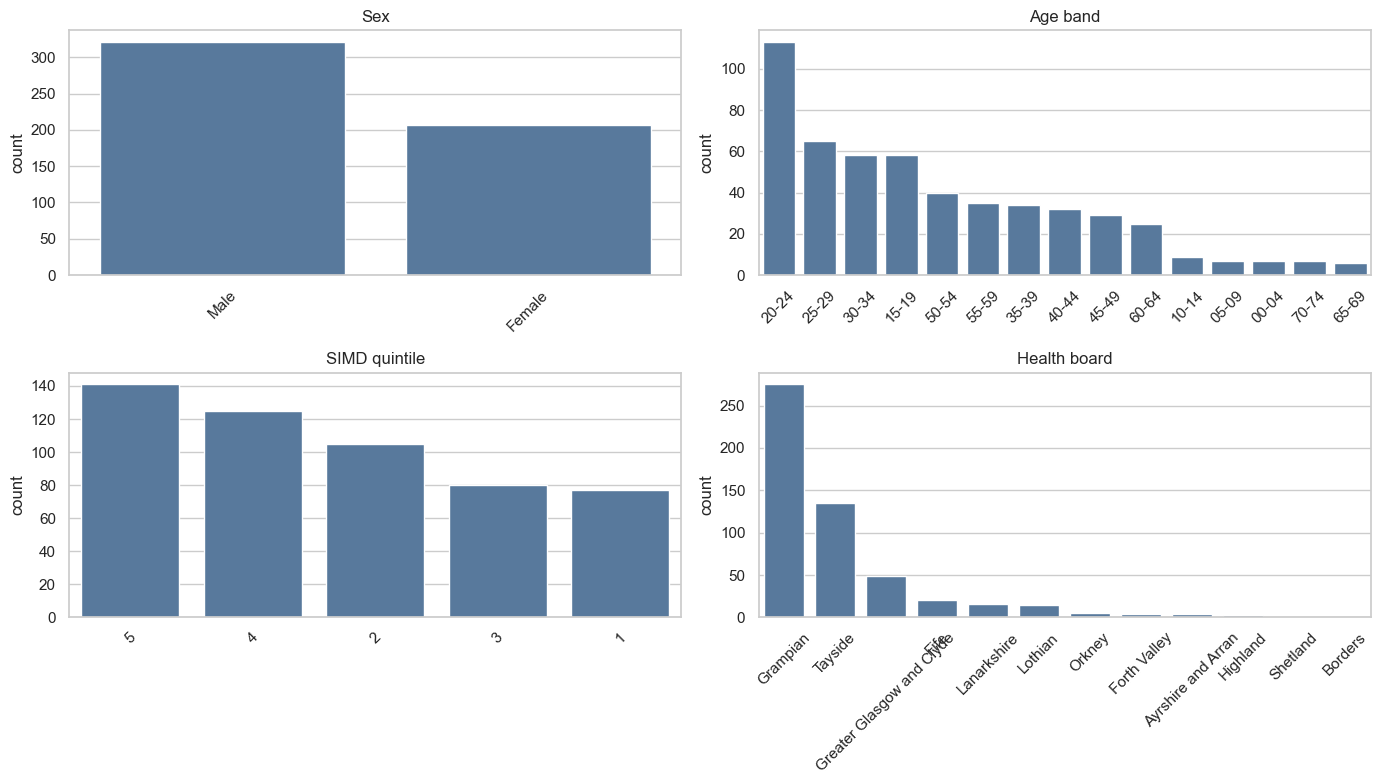

In [10]:
display(node_meta.describe(include="all"))

plot_columns = [
    ("sex", "Sex"),
    ("age_band", "Age band"),
    ("dz_simd_quintile", "SIMD quintile"),
    ("dz_health_board", "Health board"),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.ravel()

for ax, (column, title) in zip(axes, plot_columns):
    values = node_meta[column].dropna()
    
    order = values.value_counts().index[:15]

    sns.countplot(data=node_meta, x=column, order=order, ax=ax, color="#4C78A8")
    ax.set_title(title)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## Edge-weight distribution

The threshold controls graph density and the total retained compatibility weight. Inspecting the weight distribution helps identify whether downstream summaries are driven by many near-threshold edges or by a smaller number of high-compatibility pairs.


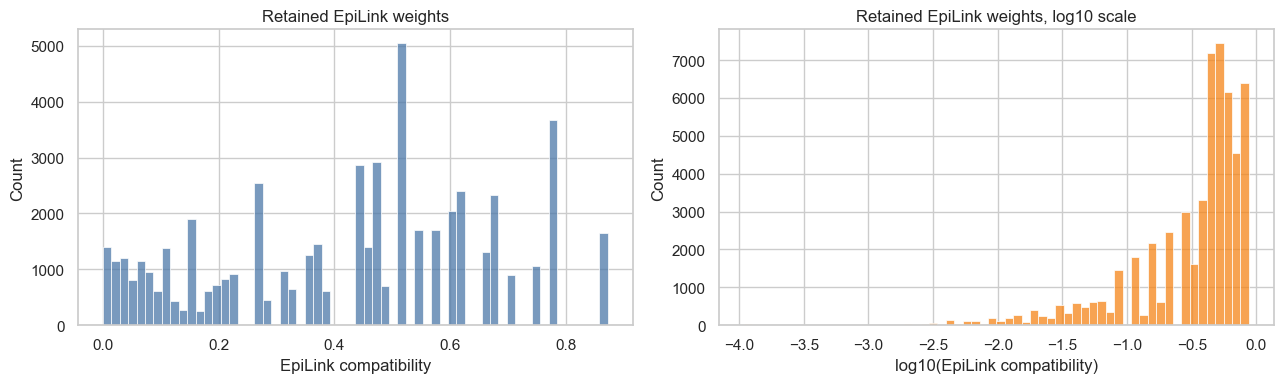

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(data=edges, x="weight", bins=60, ax=axes[0], color="#4C78A8")
axes[0].set_title("Retained EpiLink weights")
axes[0].set_xlabel("EpiLink compatibility")

sns.histplot(np.log10(edges["weight"]), bins=60, ax=axes[1], color="#F58518")
axes[1].set_title("Retained EpiLink weights, log10 scale")
axes[1].set_xlabel("log10(EpiLink compatibility)")

plt.tight_layout()
plt.show()

## Weighted mixing and assortativity helpers

Weighted mixing matrices sum EpiLink compatibility across endpoint attribute pairs. For an undirected graph, each edge contributes once in each direction so rows and columns have the same interpretation.

Categorical assortativity is the Newman mixing coefficient computed from the weighted mixing matrix. Positive values indicate more within-category compatibility weight than expected under the weighted marginal distribution.


In [12]:
def weighted_mixing_matrix(
    edge_frame: pd.DataFrame,
    node_frame: pd.DataFrame,
    attribute: str,
    *,
    normalize: bool = True,
) -> pd.DataFrame:
    """Return an undirected weighted mixing matrix for a node attribute."""
    if attribute not in node_frame.columns:
        raise KeyError(f"{attribute!r} is not in node metadata")

    attr = node_frame[attribute].rename("attribute")
    e = (
        edge_frame.join(attr.rename("source_attr"), on="source")
        .join(attr.rename("target_attr"), on="target")
        .dropna(subset=["source_attr", "target_attr", "weight"])
    )

    forward = e[["source_attr", "target_attr", "weight"]].rename(
        columns={"source_attr": "row_attr", "target_attr": "col_attr"}
    )
    reverse = e[["target_attr", "source_attr", "weight"]].rename(
        columns={"target_attr": "row_attr", "source_attr": "col_attr"}
    )
    both_directions = pd.concat([forward, reverse], ignore_index=True)

    matrix = both_directions.pivot_table(
        index="row_attr",
        columns="col_attr",
        values="weight",
        aggfunc="sum",
        fill_value=0.0,
    )

    matrix = matrix.sort_index(axis=0).sort_index(axis=1)
    if normalize and matrix.to_numpy().sum() > 0:
        matrix = matrix / matrix.to_numpy().sum()

    return matrix


def categorical_assortativity_from_mixing(mixing: pd.DataFrame) -> float:
    """Compute Newman's categorical assortativity from a weighted mixing matrix."""
    total = mixing.to_numpy().sum()
    if total <= 0:
        return np.nan

    e = mixing / total
    observed_same = float(np.trace(e.to_numpy()))
    row_margins = e.sum(axis=1)
    col_margins = e.sum(axis=0)
    expected_same = float((row_margins * col_margins).sum())
    denominator = 1 - expected_same

    if np.isclose(denominator, 0):
        return np.nan
    return (observed_same - expected_same) / denominator


def weighted_edge_correlation(
    edge_frame: pd.DataFrame,
    node_frame: pd.DataFrame,
    attribute: str,
) -> float:
    """Weighted Pearson correlation between endpoint values for an ordinal attribute."""
    values = pd.to_numeric(node_frame[attribute], errors="coerce").rename("value")
    e = (
        edge_frame.join(values.rename("x"), on="source")
        .join(values.rename("y"), on="target")
        .dropna(subset=["x", "y", "weight"])
    )
    if e.empty:
        return np.nan

    x = e["x"].to_numpy(dtype=float)
    y = e["y"].to_numpy(dtype=float)
    w = e["weight"].to_numpy(dtype=float)

    x_bar = np.average(x, weights=w)
    y_bar = np.average(y, weights=w)
    cov_xy = np.average((x - x_bar) * (y - y_bar), weights=w)
    var_x = np.average((x - x_bar) ** 2, weights=w)
    var_y = np.average((y - y_bar) ** 2, weights=w)

    if np.isclose(var_x, 0) or np.isclose(var_y, 0):
        return np.nan
    return cov_xy / np.sqrt(var_x * var_y)

## Weighted categorical assortativity

These coefficients summarise whether compatibility weight concentrates within the same metadata category more than expected from category prevalence in the weighted graph.


In [13]:
assortativity_attributes = [
    "sex",
    "age_band",
    "dz_simd_quintile",
    "dz_health_board",
    "dz_local_authority",
]

assortativity_rows = []
for attribute in assortativity_attributes:
    if attribute not in node_meta.columns:
        continue
    if node_meta[attribute].nunique(dropna=True) < 2:
        continue

    mixing = weighted_mixing_matrix(edges, node_meta, attribute, normalize=True)
    assortativity_rows.append(
        {
            "attribute": attribute,
            "levels": node_meta[attribute].nunique(dropna=True),
            "weighted_assortativity": categorical_assortativity_from_mixing(mixing),
            "endpoint_weight_with_observed_attribute": mixing.to_numpy().sum(),
        }
    )

assortativity = pd.DataFrame(assortativity_rows).sort_values(
    "weighted_assortativity", ascending=False
)
display(assortativity)

simd_weighted_correlation = weighted_edge_correlation(edges, node_meta, "dz_simd_quintile")
print(f"Weighted endpoint correlation for SIMD quintile: {simd_weighted_correlation:.3f}")

,attribute,levels,weighted_assortativity,endpoint_weight_with_observed_attribute
3,dz_health_board,12,0.594263,1.0
4,dz_local_authority,25,0.188110,1.0
2,dz_simd_quintile,5,0.049812,1.0
1,age_band,16,0.012552,1.0
0,sex,2,-0.001273,1.0


Weighted endpoint correlation for SIMD quintile: 0.207


## Observed/expected mixing heatmaps

The heatmaps show log2 observed-to-expected weighted mixing. Values above zero indicate more compatibility weight than expected under the endpoint marginals; values below zero indicate less.


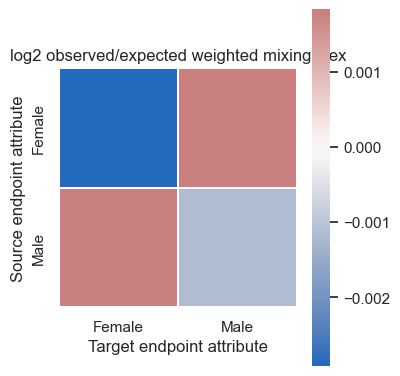

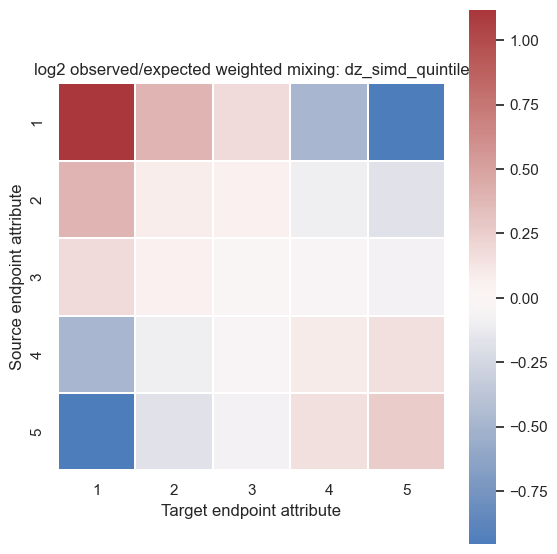

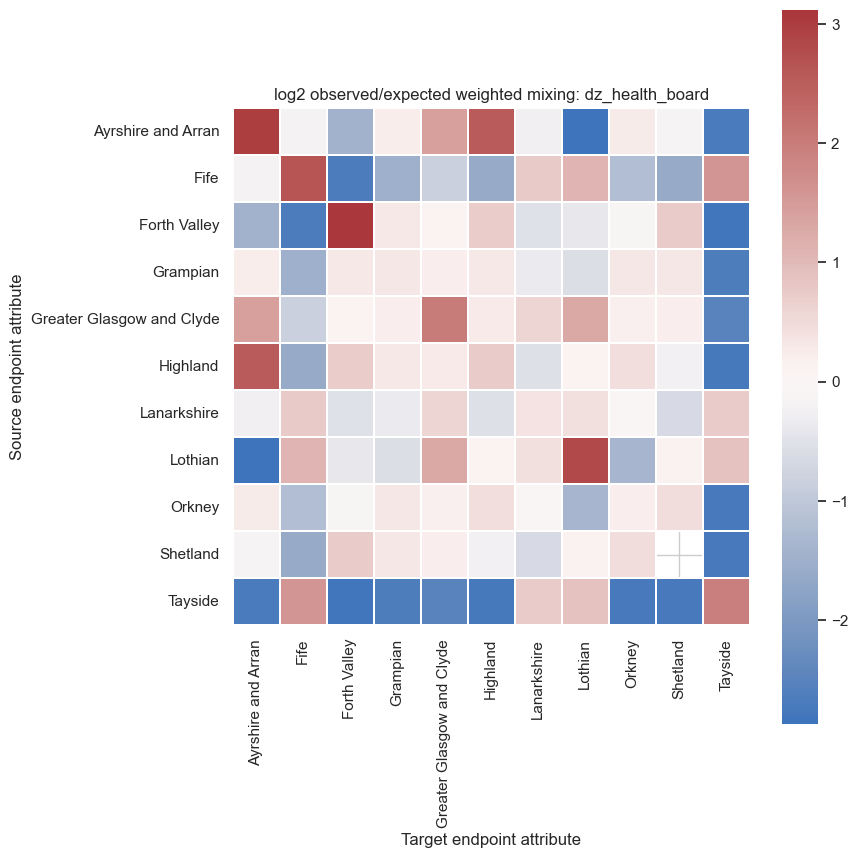

In [14]:
heatmap_attributes = ["sex", "dz_simd_quintile", "dz_health_board"]

for attribute in heatmap_attributes:
    if attribute not in node_meta.columns or node_meta[attribute].nunique(dropna=True) < 2:
        continue

    mixing = weighted_mixing_matrix(edges, node_meta, attribute, normalize=True)
    row_margins = mixing.sum(axis=1)
    col_margins = mixing.sum(axis=0)
    expected = pd.DataFrame(
        np.outer(row_margins, col_margins),
        index=mixing.index,
        columns=mixing.columns,
    )
    log2_oe = pd.DataFrame(
        np.log2(mixing.div(expected)),
        index=mixing.index,
        columns=mixing.columns,
    ).replace([np.inf, -np.inf], np.nan)

    size = max(4, min(11, 0.55 * len(mixing) + 3))
    plt.figure(figsize=(size, size))
    sns.heatmap(log2_oe, center=0, cmap="vlag", linewidths=0.3, square=True)
    plt.title(f"log2 observed/expected weighted mixing: {attribute}")
    plt.xlabel("Target endpoint attribute")
    plt.ylabel("Source endpoint attribute")
    plt.tight_layout()
    plt.show()

## Node-level strength

Weighted degree, or node strength, is the sum of EpiLink compatibility weights incident on a node. High-strength nodes are not necessarily direct transmitters; they are sequences with many or strong compatible pairwise relationships in this slice.


,sequence_id,strength,degree,collection_date,sex,age_band,dz_simd_quintile,dz_health_board
sequence_id,,,,,,,,
Scotland/EDB7354/2020,Scotland/EDB7354/2020,171.651389,301,2020-08-10,Male,15-19,3,Grampian
Scotland/QEUH-95E27D/2020,Scotland/QEUH-95E27D/2020,170.984551,301,2020-08-10,Male,60-64,2,Grampian
Scotland/QEUH-961FBC/2020,Scotland/QEUH-961FBC/2020,170.875780,301,2020-08-10,Male,15-19,5,Grampian
Scotland/QEUH-961FDA/2020,Scotland/QEUH-961FDA/2020,170.875780,301,2020-08-10,Male,05-09,4,Grampian
Scotland/QEUH-965AE4/2020,Scotland/QEUH-965AE4/2020,170.875780,301,2020-08-10,Male,45-49,2,Tayside
Scotland/QEUH-963907/2020,Scotland/QEUH-963907/2020,170.875780,301,2020-08-10,Male,55-59,5,Grampian
Scotland/QEUH-9636E2/2020,Scotland/QEUH-9636E2/2020,170.875780,301,2020-08-10,Male,30-34,4,Grampian
Scotland/QEUH-962FE8/2020,Scotland/QEUH-962FE8/2020,170.875780,301,2020-08-10,Female,50-54,5,Grampian
Scotland/QEUH-95E468/2020,Scotland/QEUH-95E468/2020,170.875780,301,2020-08-10,Female,20-24,5,Grampian


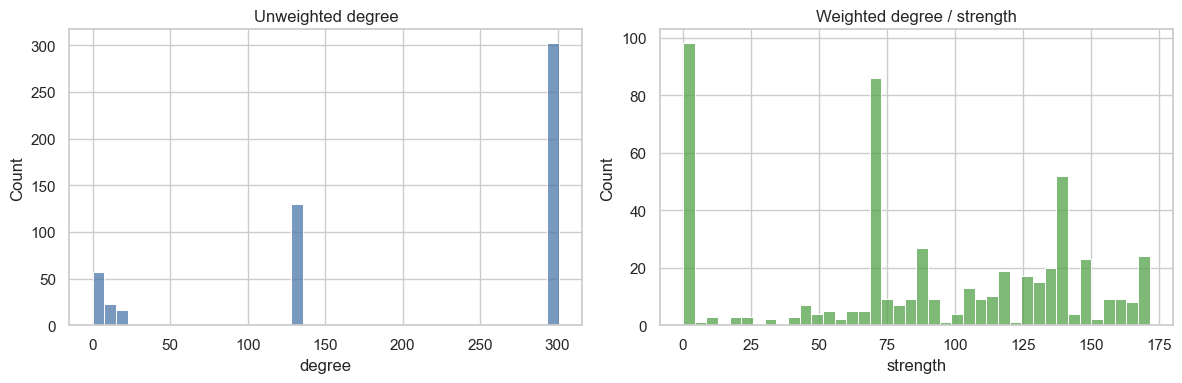

In [17]:
strength = pd.Series(dict(G.degree(weight="weight")), name="strength")
degree = pd.Series(dict(G.degree()), name="degree")

node_metrics = node_meta.join(strength).join(degree)
node_metrics[["strength", "degree"]] = node_metrics[["strength", "degree"]].fillna(0)

display(
    node_metrics[
        [
            "sequence_id",
            "strength",
            "degree",
            "collection_date",
            "sex",
            "age_band",
            "dz_simd_quintile",
            "dz_health_board",
        ]
    ]
    .sort_values("strength", ascending=False)
    .head(15)
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(node_metrics, x="degree", bins=40, ax=axes[0], color="#4C78A8")
axes[0].set_title("Unweighted degree")
sns.histplot(node_metrics, x="strength", bins=40, ax=axes[1], color="#54A24B")
axes[1].set_title("Weighted degree / strength")
plt.tight_layout()
plt.show()

## Threshold sensitivity

Low EpiLink scores can create very dense graphs. This section reruns graph summaries across stricter thresholds using the already loaded edge slice. It shows how much edge count, total compatibility weight, connectivity, and SIMD assortativity change as near-threshold edges are removed.


,threshold,n_edges,density,components,largest_component_size,isolates,retained_weight_fraction,simd_weighted_correlation
0,0.0001,54176,0.389397,24,302,7,1.000000,0.206707
1,0.0003,54139,0.389131,24,302,7,1.000000,0.206707
2,0.0010,54103,0.388872,26,302,8,0.999999,0.206707
3,0.0030,53999,0.388125,29,302,9,0.999989,0.206709
4,0.0100,53330,0.383316,30,302,10,0.999801,0.206758
5,0.0300,51587,0.370788,32,302,12,0.998321,0.207052


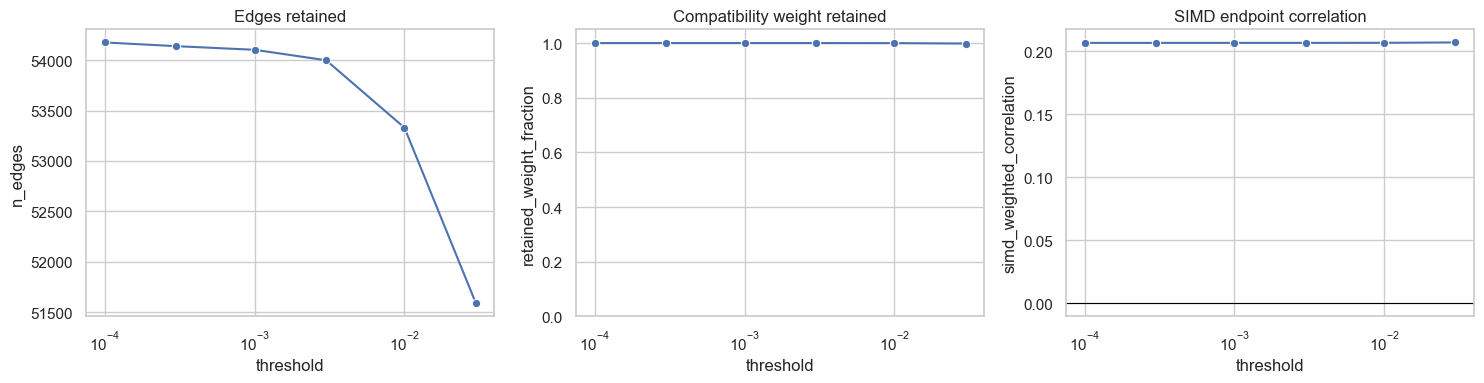

In [ ]:
threshold_grid = np.array([EDGE_THRESHOLD, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2])
base_total_weight = edges["weight"].sum()

sensitivity_rows = []
for threshold in threshold_grid:
    e = edges.loc[edges["weight"].ge(threshold)].copy()
    H = nx.Graph()
    H.add_nodes_from(node_meta.index)
    H.add_weighted_edges_from(e[["source", "target", "weight"]].itertuples(index=False, name=None))

    components = list(nx.connected_components(H))
    largest_component = max((len(c) for c in components), default=0)
    simd_r = (
        weighted_edge_correlation(e, node_meta, "dz_simd_quintile")
        if not e.empty
        else np.nan
    )

    sensitivity_rows.append(
        {
            "threshold": threshold,
            "n_edges": len(e),
            "density": nx.density(H),
            "components": len(components),
            "largest_component_size": largest_component,
            "isolates": nx.number_of_isolates(H),
            "retained_weight_fraction": e["weight"].sum() / base_total_weight,
            "simd_weighted_correlation": simd_r,
        }
    )

sensitivity = pd.DataFrame(sensitivity_rows)
display(sensitivity)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.lineplot(data=sensitivity, x="threshold", y="n_edges", marker="o", ax=axes[0])
axes[0].set_xscale("log")
axes[0].set_title("Edges retained")

sns.lineplot(data=sensitivity, x="threshold", y="retained_weight_fraction", marker="o", ax=axes[1])
axes[1].set_xscale("log")
axes[1].set_ylim(0, 1.05)
axes[1].set_title("Compatibility weight retained")

sns.lineplot(data=sensitivity, x="threshold", y="simd_weighted_correlation", marker="o", ax=axes[2])
axes[2].set_xscale("log")
axes[2].axhline(0, color="black", linewidth=0.8)
axes[2].set_title("SIMD endpoint correlation")

plt.tight_layout()
plt.show()

## Notes for broader runs

To analyse more than one group, widen `TARGET_WINDOW_ID`, `TARGET_CLADE`, or `TARGET_PANGO_LINEAGES` deliberately and add a preflight row-count step before reading. The broad filter pattern below is valid, but it is usually too large for an interactive notebook without additional constraints:

```python
load_pairwise_edges(
    columns=["id1", "id2", "window_id", "pango_lineage", "epilink_compatibility"],
    windows=["W001", "W003", "W005"],
    clades="20B",
    compatibility_threshold=EDGE_THRESHOLD,
)
```

If you keep `window_stride=2`, preserve original labels with `renumber_windows=False` unless you also transform the pairwise `window_id` values in the same way.
